# Mean Curvature Flow of Planar Curves

For a curve $\Gamma_t$, mean-curvature flow evolves normal velocity as:
$$
V_n = -\kappa,
$$
which smooths and shrinks shapes. In discrete form, Laplacian smoothing of polygon vertices provides a didactic approximation.


## Environment

We import numerical and plotting libraries and define a robust output directory for figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/mean-curvature-flow") if Path("python/mean-curvature-flow").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Initialize a non-convex closed curve

We use a star-like radial profile and evolve it with periodic second differences.


In [2]:
n = 320
t = np.linspace(0, 2*np.pi, n, endpoint=False)
r = 1.0 + 0.25*np.cos(5*t) + 0.08*np.sin(9*t)
X = np.c_[r*np.cos(t), r*np.sin(t)]

def step_curve(P, dt=0.05):
    return P + dt*(np.roll(P, -1, axis=0) - 2*P + np.roll(P, 1, axis=0))

snap_ids = [0, 60, 140, 260]
snaps = []
P = X.copy()
for k in range(max(snap_ids)+1):
    if k in snap_ids:
        snaps.append((k, P.copy()))
    P = step_curve(P, dt=0.04)
    P -= P.mean(axis=0, keepdims=True)  # recenter for visualization


## Shape evolution snapshots

The curve progressively loses high-curvature oscillations and approaches a circle before collapsing.


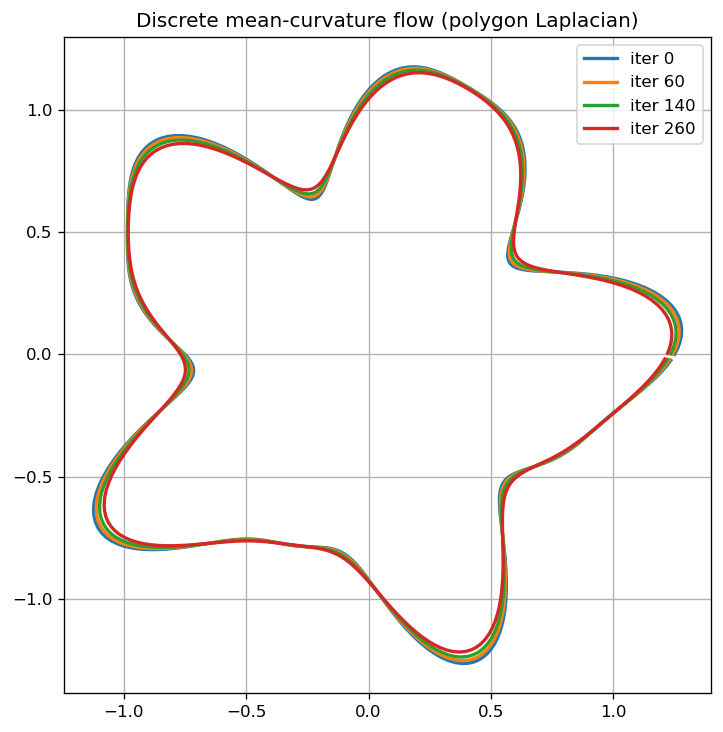

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
for k, Pk in snaps:
    ax.plot(Pk[:, 0], Pk[:, 1], lw=2, label=f"iter {k}")
ax.set_aspect("equal")
ax.set_title("Discrete mean-curvature flow (polygon Laplacian)")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- S. Osher, J. A. Sethian, "Fronts Propagating with Curvature-Dependent Speed", JCP, 1988.
- L. C. Evans, J. Spruck, "Motion of Level Sets by Mean Curvature I", JDE, 1991.
- G. Sapiro, *Geometric Partial Differential Equations and Image Analysis*, Cambridge Univ. Press, 2001.
